# CareAssist EDA - Foster Care Data Analysis
## Initial Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

In [2]:
# Creating dataframes for each year. 2019 is different is separated by tabs.
data_2019 = pd.read_csv('dataset\FC2019ABv1.csv', sep='\t', low_memory=False) #ignore for now
data_2020 = pd.read_csv('dataset\FC2020ABv1.csv', low_memory=False)
data_2021 = pd.read_csv('dataset\FC2021ABv1.csv', low_memory=False)
data_2022 = pd.read_csv('dataset\FC2022ABv1.csv', low_memory=False)
data_2023 = pd.read_csv('dataset\FC2023ABv1.csv', low_memory=False)
data_2024 = pd.read_csv('dataset\FC2024ABv1.csv', low_memory=False)

<>:2: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:4: SyntaxWarning: invalid escape sequence '\F'
<>:5: SyntaxWarning: invalid escape sequence '\F'
<>:6: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\F'
<>:2: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:4: SyntaxWarning: invalid escape sequence '\F'
<>:5: SyntaxWarning: invalid escape sequence '\F'
<>:6: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\F'
C:\Users\prisc\AppData\Local\Temp\ipykernel_20284\3115583460.py:2: SyntaxWarning: invalid escape sequence '\F'
  data_2019 = pd.read_csv('dataset\FC2019ABv1.csv', sep='\t', low_memory=False) #ignore for now
C:\Users\prisc\AppData\Local\Temp\ipykernel_20284\3115583460.py:3: SyntaxWarning: invalid escape sequence '\F'
  data_2020 = pd.read_csv('dataset\FC2020ABv1.csv', low_memory=False)
C:\Users\pri

## Combine DataFrames

In [3]:
dataframes_list = [data_2020, data_2021, data_2022, data_2023, data_2024] # remove 2019

# Tag each row with its source year before combining
for year, df in zip(range(2020, 2025), dataframes_list):
    df['source_year'] = year

combined_data = pd.concat(dataframes_list, ignore_index=True)
print(f"Combined DataFrame shape before deduplication: {combined_data.shape}")

# Keep one record per child per year (stfcid + source_year).
# This preserves a child's full history across years while removing
# true duplicates within a single year's file.
combined_data = (
    combined_data
    .drop_duplicates(subset=['StFCID', 'source_year'], keep='first')
    .reset_index(drop=True)
)

# Standardize column names to lowercase for consistency
combined_data.columns = combined_data.columns.str.lower()

print(f"Combined DataFrame shape after deduplication: {combined_data.shape}")
print(f"Unique children (stfcid): {combined_data['stfcid'].nunique():,}")
print(f"Unique child-year records: {combined_data[['stfcid', 'source_year']].drop_duplicates().shape[0]:,}")
print(combined_data.head())

# Save the combined DataFrame to a CSV file
# combined_data.to_csv('/content/combined_data.csv', index=False)
# print("Combined DataFrame saved to /content/combined_data.csv")

Combined DataFrame shape before deduplication: (2879158, 105)
Combined DataFrame shape after deduplication: (2879092, 105)
Unique children (stfcid): 1,311,434
Unique child-year records: 2,879,092
     fy  version  state  st  repdatyr  repdatmo  fipscode      recnumbr  sex  \
0  2020        1     37  NC      2020         9         8  R99044225246  2.0   
1  2020        1     37  NC      2020         9         8  R99044231032  1.0   
2  2020        1     37  NC      2020         9     37051  R99044231063  1.0   
3  2020        1     37  NC      2020         9         8  R99044232374  2.0   
4  2020        1     37  NC      2020         9         8  R99044238028  1.0   

   amiakn  asian  blkafram  hawaiipi  white  untodetm  hisorgin  clindis   mr  \
0     1.0    0.0       0.0       0.0    0.0       0.0       2.0      2.0  0.0   
1     0.0    0.0       0.0       0.0    1.0       0.0       2.0      2.0  0.0   
2     0.0    0.0       0.0       0.0    0.0       1.0       2.0      2.0  0.0   

In [4]:
# dataframes_list = [data_2019, data_2020, data_2021, data_2022, data_2023, data_2024]
# combined_data = pd.concat(dataframes_list, ignore_index=True)
# print(f"Combined DataFrame shape: {combined_data.shape}")
# print(combined_data.head())

# Save the combined DataFrame to a CSV file
# combined_data.to_csv('/content/combined_data.csv', index=False)
# print("Combined DataFrame saved to /content/combined_data.csv")

In [5]:
print("Overall lifelos percentiles:\n", combined_data['lifelos'].quantile([0.5, 0.75, 0.9]))
print("\nOverall totalrem percentiles:\n", combined_data['totalrem'].quantile([0.5, 0.75, 0.9]))
print("\nOverall numplep percentiles:\n", combined_data['numplep'].quantile([0.5, 0.75, 0.9]))

Overall lifelos percentiles:
 0.50     546.0
0.75     997.0
0.90    1619.0
Name: lifelos, dtype: float64

Overall totalrem percentiles:
 0.50    1.0
0.75    1.0
0.90    2.0
Name: totalrem, dtype: float64

Overall numplep percentiles:
 0.50    2.0
0.75    3.0
0.90    6.0
Name: numplep, dtype: float64


# STEP 1: Separate Data by Age Ranges
## Using AgeAtLatRem (Age at Most Recent Removal)

**Rationale**: Using AgeAtLatRem makes more theoretical sense because:
- It reflects the child's developmental stage at the time they entered care
- Removal reasons, instability, and permanency processes are tied to entry circumstances
- AgeAtStart could misclassify children who crossed a birthday by October 1
- Entry age is more predictive of outcomes and service needs

In [6]:
# Define age groups based on AgeAtLatRem
def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 2:
        return '0-2'
    elif age <= 5:
        return '3-5'
    elif age <= 9:
        return '6-9'
    elif age <= 13:
        return '10-13'
    elif age <= 17:
        return '14-17'
    else:
        return '18+'

combined_data['age_group'] = combined_data['ageatlatrem'].apply(categorize_age)

# Display distribution
print("\nAge Group Distribution:")
print(combined_data['age_group'].value_counts().sort_index())
print(f"\nPercentage Distribution:")
print(combined_data['age_group'].value_counts(normalize=True).sort_index() * 100)


Age Group Distribution:
age_group
0-2      958297
10-13    484731
14-17    425336
18+       33306
3-5      462808
6-9      514614
Name: count, dtype: int64

Percentage Distribution:
age_group
0-2      33.284695
10-13    16.836246
14-17    14.773269
18+       1.156823
3-5      16.074790
6-9      17.874177
Name: proportion, dtype: float64


In [7]:
# Create separate dataframes for each age group
age_0_2 = combined_data[combined_data['age_group'] == '0-2'].copy()
age_3_5 = combined_data[combined_data['age_group'] == '3-5'].copy()
age_6_9 = combined_data[combined_data['age_group'] == '6-9'].copy()
age_10_13 = combined_data[combined_data['age_group'] == '10-13'].copy()
age_14_17 = combined_data[combined_data['age_group'] == '14-17'].copy()
age_18_plus = combined_data[combined_data['age_group'] == '18+'].copy()

print(f"Age 0-2: {len(age_0_2):,} records")
print(f"Age 3-5: {len(age_3_5):,} records")
print(f"Age 6-9: {len(age_6_9):,} records")
print(f"Age 10-13: {len(age_10_13):,} records")
print(f"Age 14-17: {len(age_14_17):,} records")
print(f"Age 18+: {len(age_18_plus):,} records")

Age 0-2: 958,297 records
Age 3-5: 462,808 records
Age 6-9: 514,614 records
Age 10-13: 484,731 records
Age 14-17: 425,336 records
Age 18+: 33,306 records


# STEP 2: Missing Values Analysis
## Analyze NULL/Missing Values for Key Variables

In [8]:
# Define all variables of interest across domains
domain_variables = {
    'Placement Instability': ['totalrem', 'numplep', 'lifelos', 'latremlos'],
    'Safety & Removal Context': ['phyabuse', 'sexabuse', 'neglect', 'darem', 'daparent',
                                   'aarem', 'aaparent', 'dachild', 'aachild', 'abandmnt',
                                   'nocope', 'prtsjail', 'housing'],
    'Health & Special Needs': ['clindis', 'emotdist', 'phydis', 'mr', 'vishear', 'othermed'],
    'Legal & Permanency': ['prtsdied', 'istpr', 'iswaiting', 'relinqsh'],
    'Age-Related': ['ageatlatrem', 'agedout'],
    'Current Placement': ['disreasn']
}

# Flatten the list of all variables
all_variables = [var for vars_list in domain_variables.values() for var in vars_list]

# Check which variables exist in the dataset
existing_vars = [var for var in all_variables if var in combined_data.columns]
missing_vars = [var for var in all_variables if var not in combined_data.columns]

print("Variables found in dataset:")
print(existing_vars)
print(f"\nVariables NOT found in dataset:")
print(missing_vars)

Variables found in dataset:
['totalrem', 'numplep', 'lifelos', 'latremlos', 'phyabuse', 'sexabuse', 'neglect', 'daparent', 'aaparent', 'dachild', 'aachild', 'abandmnt', 'nocope', 'prtsjail', 'housing', 'clindis', 'emotdist', 'phydis', 'mr', 'vishear', 'othermed', 'prtsdied', 'istpr', 'iswaiting', 'relinqsh', 'ageatlatrem', 'agedout', 'disreasn']

Variables NOT found in dataset:
['darem', 'aarem']


In [9]:
# Create comprehensive missing value report
def missing_values_analysis(df, variables, title="Missing Values Analysis"):
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}")

    missing_data = []
    for var in variables:
        if var in df.columns:
            total = len(df)
            missing = df[var].isna().sum()
            pct = (missing / total) * 100
            missing_data.append({
                'Variable': var,
                'Missing Count': missing,
                'Total Count': total,
                'Missing %': round(pct, 2),
                'Present Count': total - missing
            })

    missing_df = pd.DataFrame(missing_data)
    missing_df = missing_df.sort_values('Missing %', ascending=False)
    return missing_df

# Overall missing values
overall_missing = missing_values_analysis(combined_data, existing_vars, "Overall Dataset")
print(overall_missing.to_string(index=False))


Overall Dataset
   Variable  Missing Count  Total Count  Missing %  Present Count
   othermed         799242      2879092      27.76        2079850
   emotdist         796977      2879092      27.68        2082115
     phydis         795800      2879092      27.64        2083292
         mr         795252      2879092      27.62        2083840
    vishear         792429      2879092      27.52        2086663
   abandmnt         221701      2879092       7.70        2657391
   prtsjail         216397      2879092       7.52        2662695
     nocope         194189      2879092       6.74        2684903
    lifelos         136127      2879092       4.73        2742965
    clindis          94778      2879092       3.29        2784314
   aaparent          92798      2879092       3.22        2786294
    housing          63986      2879092       2.22        2815106
    neglect          58422      2879092       2.03        2820670
   daparent          42010      2879092       1.46        2

In [10]:
# Special focus on LifeLOS and TotalRem relationship
print("\n" + "="*80)
print("LIFELOS ANALYSIS: Understanding NULL patterns")
print("="*80)

# Analyze TotalRem distribution
print("\nTotalRem Distribution:")
totalrem_dist = combined_data['totalrem'].value_counts().sort_index()
print(totalrem_dist)

print(f"\nCases where TotalRem > 2: {(combined_data['totalrem'] > 2).sum():,}")
print(f"Percentage: {(combined_data['totalrem'] > 2).sum() / len(combined_data) * 100:.2f}%")

print(f"\nCases where TotalRem is NULL: {combined_data['totalrem'].isna().sum():,}")
print(f"Percentage: {combined_data['totalrem'].isna().sum() / len(combined_data) * 100:.2f}%")

# Analyze LifeLOS based on TotalRem
print("\nLifeLOS NULL status by TotalRem:")
for totalrem_val in [1, 2]:
    subset = combined_data[combined_data['totalrem'] == totalrem_val]
    lifelos_null = subset['lifelos'].isna().sum()
    print(f"TotalRem = {totalrem_val}: {lifelos_null:,} NULL LifeLOS ({lifelos_null/len(subset)*100:.2f}%)")

subset_gt2 = combined_data[combined_data['totalrem'] > 2]
lifelos_null_gt2 = subset_gt2['lifelos'].isna().sum()
print(f"TotalRem > 2: {lifelos_null_gt2:,} NULL LifeLOS ({lifelos_null_gt2/len(subset_gt2)*100:.2f}%)")

subset_null_rem = combined_data[combined_data['totalrem'].isna()]
lifelos_null_null_rem = subset_null_rem['lifelos'].isna().sum()
print(f"TotalRem NULL: {lifelos_null_null_rem:,} NULL LifeLOS ({lifelos_null_null_rem/len(subset_null_rem)*100:.2f}%)")


LIFELOS ANALYSIS: Understanding NULL patterns

TotalRem Distribution:
totalrem
1.0     2310991
2.0      438797
3.0       97257
4.0       22109
5.0        5075
6.0        1234
7.0         340
8.0         121
9.0          69
10.0         18
11.0         10
12.0         11
13.0          2
14.0          1
Name: count, dtype: int64

Cases where TotalRem > 2: 126,247
Percentage: 4.38%

Cases where TotalRem is NULL: 3,057
Percentage: 0.11%

LifeLOS NULL status by TotalRem:
TotalRem = 1: 324 NULL LifeLOS (0.01%)
TotalRem = 2: 6,499 NULL LifeLOS (1.48%)
TotalRem > 2: 126,247 NULL LifeLOS (100.00%)
TotalRem NULL: 3,057 NULL LifeLOS (100.00%)


In [11]:
# Missing values by age group
print("\n" + "="*80)
print("MISSING VALUES BY AGE GROUP")
print("="*80)

for age_group_name, age_df in [('0-2', age_0_2), ('3-5', age_3_5), ('6-9', age_6_9),
                                 ('10-13', age_10_13), ('14-17', age_14_17), ('18+', age_18_plus)]:
    missing_by_age = missing_values_analysis(age_df, existing_vars, f"Age Group {age_group_name}")
    # Show only variables with >5% missing
    high_missing = missing_by_age[missing_by_age['Missing %'] > 5]
    if len(high_missing) > 0:
        print(high_missing.to_string(index=False))
    print()


MISSING VALUES BY AGE GROUP

Age Group 0-2
Variable  Missing Count  Total Count  Missing %  Present Count
othermed         283194       958297      29.55         675103
      mr         282345       958297      29.46         675952
  phydis         282271       958297      29.46         676026
emotdist         282243       958297      29.45         676054
 vishear         281661       958297      29.39         676636
abandmnt          71536       958297       7.46         886761
prtsjail          69399       958297       7.24         888898
  nocope          61747       958297       6.44         896550


Age Group 3-5
Variable  Missing Count  Total Count  Missing %  Present Count
othermed         131721       462808      28.46         331087
  phydis         131303       462808      28.37         331505
      mr         131260       462808      28.36         331548
emotdist         131213       462808      28.35         331595
 vishear         130806       462808      28.26         33

In [12]:
# ================================================================================
# Age Group 6-9
# ================================================================================
# Variable  Missing Count  Total Count  Missing %  Present Count
# othermed         137858       514614      26.79         376756
# emotdist         137222       514614      26.67         377392
#   phydis         137219       514614      26.66         377395
#       mr         137075       514614      26.64         377539
#  vishear         136524       514614      26.53         378090
# abandmnt          38825       514614       7.54         475789
# prtsjail          37482       514614       7.28         477132
#   nocope          33735       514614       6.56         480879
#  lifelos          26913       514614       5.23         487701

# STEP 3: Descriptive Statistics by Age Group
## Analyze Outcomes and Key Variables

In [13]:
# Function to calculate comprehensive stats for a variable
def calculate_stats(df, variable, percentiles=[0.5, 0.75, 0.9, 0.95]):
    if variable not in df.columns:
        return None

    stats_dict = {
        'count': df[variable].count(),
        'missing': df[variable].isna().sum(),
        'mean': df[variable].mean(),
        'std': df[variable].std(),
        'min': df[variable].min(),
        'max': df[variable].max()
    }

    # Add percentiles
    for p in percentiles:
        stats_dict[f'{int(p*100)}th'] = df[variable].quantile(p)

    return stats_dict

# Create comprehensive statistics table
def age_group_statistics(age_groups_dict, variables):
    results = []

    for age_name, age_df in age_groups_dict.items():
        print(f"\n{'='*80}")
        print(f"AGE GROUP: {age_name} (N={len(age_df):,})")
        print(f"{'='*80}")

        for var in variables:
            stats = calculate_stats(age_df, var)
            if stats:
                print(f"\n{var.upper()}:")
                for key, value in stats.items():
                    if key in ['mean', 'std']:
                        print(f"  {key:12s}: {value:.2f}")
                    elif key in ['50th', '75th', '90th', '95th']:
                        print(f"  {key:12s}: {value:.2f}")
                    else:
                        print(f"  {key:12s}: {value}")

age_groups_dict = {
    '0-2': age_0_2,
    '3-5': age_3_5,
    '6-9': age_6_9,
    '10-13': age_10_13,
    '14-17': age_14_17,
    '18+': age_18_plus
}

# Focus on key outcome variables
key_outcomes = ['lifelos', 'latremlos', 'totalrem', 'numplep']
age_group_statistics(age_groups_dict, key_outcomes)


AGE GROUP: 0-2 (N=958,297)

LIFELOS:
  count       : 951254
  missing     : 7043
  mean        : 644.73
  std         : 633.05
  min         : 0.0
  max         : 7670.0
  50th        : 503.00
  75th        : 859.00
  90th        : 1303.00
  95th        : 1667.00

LATREMLOS:
  count       : 958215
  missing     : 82
  mean        : 640.13
  std         : 645.47
  min         : 0.0
  max         : 7670.0
  50th        : 493.00
  75th        : 847.00
  90th        : 1294.00
  95th        : 1667.00

TOTALREM:
  count       : 957345
  missing     : 952
  mean        : 1.06
  std         : 0.26
  min         : 1.0
  max         : 12.0
  50th        : 1.00
  75th        : 1.00
  90th        : 1.00
  95th        : 2.00

NUMPLEP:
  count       : 954675
  missing     : 3622
  mean        : 2.09
  std         : 1.94
  min         : 1.0
  max         : 115.0
  50th        : 2.00
  75th        : 2.00
  90th        : 4.00
  95th        : 5.00

AGE GROUP: 3-5 (N=462,808)

LIFELOS:
  count       : 4

In [14]:
# ================================================================================
# AGE GROUP: 6-9 (N=514,614)
# ================================================================================

# LIFELOS:
#   count       : 487701
#   missing     : 26913
#   mean        : 874.35
#   std         : 874.70
#   min         : 0.0
#   max         : 7651.0
#   50th        : 605.00
#   75th        : 1161.00
#   90th        : 2012.00
#   95th        : 2762.00

# LATREMLOS:
#   count       : 514576
#   missing     : 38
#   mean        : 804.85
#   std         : 844.58
#   min         : 0.0
#   max         : 7459.0
#   50th        : 533.00
#   75th        : 1057.00
#   90th        : 1907.00
#   95th        : 2672.00

# TOTALREM:
#   count       : 514256
#   missing     : 358
#   mean        : 1.30
#   std         : 0.60
#   min         : 1.0
#   max         : 8.0
#   50th        : 1.00
#   75th        : 1.00
#   90th        : 2.00
#   95th        : 2.00

# NUMPLEP:
#   count       : 513099
#   missing     : 1515
#   mean        : 3.51
#   std         : 4.84
#   min         : 1.0
#   max         : 183.0
#   50th        : 2.00
#   75th        : 4.00
#   90th        : 7.00
#   95th        : 11.00


## DOMAIN 1: Placement Instability Analysis

**Update:** Added a check to make sure the child has not EXITED out of the system and is also not WAITING for adoption

In [15]:
print("\n" + "="*80)
print("DOMAIN 1: PLACEMENT INSTABILITY")
print("="*80)

placement_vars = ['totalrem', 'numplep', 'lifelos', 'latremlos']

# Calculate percentile thresholds for each variable (overall)
thresholds = {}
for var in placement_vars:
    if var in combined_data.columns:
        thresholds[var] = {
            '75th': combined_data[var].quantile(0.75),
            '90th': combined_data[var].quantile(0.90)
        }

print("\nOverall Percentile Thresholds (for labeling high-risk cases):")
for var, thresh in thresholds.items():
    print(f"{var:12s}: 75th={thresh['75th']:.0f}, 90th={thresh['90th']:.0f}")

# Analyze by age group
for age_name, age_df in age_groups_dict.items():
    print(f"\n{'-'*60}")
    print(f"Age Group: {age_name}")
    print(f"{'-'*60}")

    for var in placement_vars:
        if var in age_df.columns:
            stats = calculate_stats(age_df, var, [0.25, 0.5, 0.75, 0.9])
            print(f"\n{var}:")
            print(f"  Mean: {stats['mean']:.2f} (SD: {stats['std']:.2f})")
            print(f"  Median: {stats['50th']:.0f} | 75th: {stats['75th']:.0f} | 90th: {stats['90th']:.0f}")

            # Count high-risk cases
            if var in thresholds:
                high_75 = (age_df[var] >= thresholds[var]['75th']).sum()
                high_90 = (age_df[var] >= thresholds[var]['90th']).sum()
                print(f"  High-risk (≥75th): {high_75:,} ({high_75/len(age_df)*100:.1f}%)")
                print(f"  Very high-risk (≥90th): {high_90:,} ({high_90/len(age_df)*100:.1f}%)")


DOMAIN 1: PLACEMENT INSTABILITY

Overall Percentile Thresholds (for labeling high-risk cases):
totalrem    : 75th=1, 90th=2
numplep     : 75th=3, 90th=6
lifelos     : 75th=997, 90th=1619
latremlos   : 75th=912, 90th=1501

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

totalrem:
  Mean: 1.06 (SD: 0.26)
  Median: 1 | 75th: 1 | 90th: 1
  High-risk (≥75th): 957,345 (99.9%)
  Very high-risk (≥90th): 55,121 (5.8%)

numplep:
  Mean: 2.09 (SD: 1.94)
  Median: 2 | 75th: 2 | 90th: 4
  High-risk (≥75th): 234,651 (24.5%)
  Very high-risk (≥90th): 34,323 (3.6%)

lifelos:
  Mean: 644.73 (SD: 633.05)
  Median: 503 | 75th: 859 | 90th: 1303
  High-risk (≥75th): 178,441 (18.6%)
  Very high-risk (≥90th): 51,844 (5.4%)

latremlos:
  Mean: 640.13 (SD: 645.47)
  Median: 493 | 75th: 847 | 90th: 1294
  High-risk (≥75th): 210,149 (21.9%)
  Very high-risk (≥90th): 64,583 (6.7%)

------------------------------------------

**Note**: 90th Percentile for totalrem is 2 for every age group except 0-2 where the totalrem is 1

## DOMAIN 2: Safety & Removal Context Analysis

In [16]:
print("\n" + "="*80)
print("DOMAIN 2: SAFETY & REMOVAL CONTEXT")
print("="*80)

safety_vars = ['phyabuse', 'sexabuse', 'neglect', 'darem', 'daparent',
               'aarem', 'aaparent', 'dachild', 'aachild', 'abandmnt',
               'nocope', 'prtsjail', 'housing']

# Filter to existing variables
safety_vars_exist = [v for v in safety_vars if v in combined_data.columns]

print(f"\nVariables available: {safety_vars_exist}")
print(f"Variables missing: {[v for v in safety_vars if v not in combined_data.columns]}")

# Calculate safety score (sum of all flags)
for age_name, age_df in age_groups_dict.items():
    age_df['safety_score'] = age_df[safety_vars_exist].sum(axis=1)

combined_data['safety_score'] = combined_data[safety_vars_exist].sum(axis=1)

# Overall distribution
print("\nOverall Safety Score Distribution:")
print(combined_data['safety_score'].describe())

# By age group
for age_name, age_df in age_groups_dict.items():
    print(f"\n{'-'*60}")
    print(f"Age Group: {age_name}")
    print(f"{'-'*60}")

    # Individual variable prevalence
    print("\nPrevalence of each safety indicator:")
    for var in safety_vars_exist:
        if var in age_df.columns:
            count = (age_df[var] == 1).sum()
            pct = count / len(age_df) * 100
            print(f"  {var:12s}: {count:7,} ({pct:5.2f}%)")

    # Safety score statistics
    print(f"\nSafety Score (out of {len(safety_vars_exist)}):")
    print(f"  Mean: {age_df['safety_score'].mean():.2f}")
    print(f"  Median: {age_df['safety_score'].median():.0f}")
    print(f"  75th percentile: {age_df['safety_score'].quantile(0.75):.0f}")
    print(f"  90th percentile: {age_df['safety_score'].quantile(0.90):.0f}")


DOMAIN 2: SAFETY & REMOVAL CONTEXT

Variables available: ['phyabuse', 'sexabuse', 'neglect', 'daparent', 'aaparent', 'dachild', 'aachild', 'abandmnt', 'nocope', 'prtsjail', 'housing']
Variables missing: ['darem', 'aarem']

Overall Safety Score Distribution:
count    2.879092e+06
mean     1.581003e+00
std      9.604706e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.100000e+01
Name: safety_score, dtype: float64

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

Prevalence of each safety indicator:
  phyabuse    : 103,979 (10.85%)
  sexabuse    :  10,084 ( 1.05%)
  neglect     : 657,406 (68.60%)
  daparent    : 443,024 (46.23%)
  aaparent    :  48,865 ( 5.10%)
  dachild     :  25,871 ( 2.70%)
  aachild     :   2,367 ( 0.25%)
  abandmnt    :  31,414 ( 3.28%)
  nocope      : 100,621 (10.50%)
  prtsjail    :  57,843 ( 6.04%)
  housing     : 114,708 

## DOMAIN 3: Health & Special Needs Analysis

In [17]:
print("\n" + "="*80)
print("DOMAIN 3: HEALTH & SPECIAL NEEDS")
print("="*80)

health_vars = ['clindis', 'emotdist', 'phydis', 'mr', 'vishear', 'othermed']
health_vars_exist = [v for v in health_vars if v in combined_data.columns]

print(f"\nVariables available: {health_vars_exist}")

# Calculate health complexity score
for age_name, age_df in age_groups_dict.items():
    age_df['health_score'] = age_df[health_vars_exist].sum(axis=1)

combined_data['health_score'] = combined_data[health_vars_exist].sum(axis=1)

# By age group
for age_name, age_df in age_groups_dict.items():
    print(f"\n{'-'*60}")
    print(f"Age Group: {age_name}")
    print(f"{'-'*60}")

    print("\nPrevalence of each health/special needs indicator:")
    for var in health_vars_exist:
        if var in age_df.columns:
            count = (age_df[var] == 1).sum()
            pct = count / len(age_df) * 100
            print(f"  {var:12s}: {count:7,} ({pct:5.2f}%)")

    print(f"\nHealth Complexity Score (out of {len(health_vars_exist)}):")
    print(f"  Mean: {age_df['health_score'].mean():.2f}")
    print(f"  Median: {age_df['health_score'].median():.0f}")
    print(f"  Any condition: {(age_df['health_score'] > 0).sum():,} ({(age_df['health_score'] > 0).sum()/len(age_df)*100:.1f}%)")
    print(f"  Multiple conditions: {(age_df['health_score'] > 1).sum():,} ({(age_df['health_score'] > 1).sum()/len(age_df)*100:.1f}%)")


DOMAIN 3: HEALTH & SPECIAL NEEDS

Variables available: ['clindis', 'emotdist', 'phydis', 'mr', 'vishear', 'othermed']

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

Prevalence of each health/special needs indicator:
  clindis     : 168,441 (17.58%)
  emotdist    :  31,383 ( 3.27%)
  phydis      :  17,297 ( 1.80%)
  mr          :  23,564 ( 2.46%)
  vishear     :  17,837 ( 1.86%)
  othermed    : 150,987 (15.76%)

Health Complexity Score (out of 6):
  Mean: 2.24
  Median: 2
  Any condition: 926,864 (96.7%)
  Multiple conditions: 923,758 (96.4%)

------------------------------------------------------------
Age Group: 3-5
------------------------------------------------------------

Prevalence of each health/special needs indicator:
  clindis     :  96,660 (20.89%)
  emotdist    :  55,273 (11.94%)
  phydis      :   6,252 ( 1.35%)
  mr          :  10,107 ( 2.18%)
  vishear     :  11,753 ( 2.54%)
  ot

## DOMAIN 4: Legal & Permanency Complexity

In [18]:
print("\n" + "="*80)
print("DOMAIN 4: LEGAL & PERMANENCY COMPLEXITY")
print("="*80)

legal_vars = ['prtsdied', 'istpr', 'iswaiting', 'relinqsh']
legal_vars_exist = [v for v in legal_vars if v in combined_data.columns]

print(f"\nVariables available: {legal_vars_exist}")

# Calculate legal complexity score
for age_name, age_df in age_groups_dict.items():
    age_df['legal_score'] = age_df[legal_vars_exist].sum(axis=1)

combined_data['legal_score'] = combined_data[legal_vars_exist].sum(axis=1)

# By age group
for age_name, age_df in age_groups_dict.items():
    print(f"\n{'-'*60}")
    print(f"Age Group: {age_name}")
    print(f"{'-'*60}")

    print("\nPrevalence of legal/permanency indicators:")
    for var in legal_vars_exist:
        if var in age_df.columns:
            count = (age_df[var] == 1).sum()
            pct = count / len(age_df) * 100
            print(f"  {var:12s}: {count:7,} ({pct:5.2f}%)")

    print(f"\nLegal Complexity Score:")
    print(f"  Mean: {age_df['legal_score'].mean():.2f}")
    print(f"  Any legal complexity: {(age_df['legal_score'] > 0).sum():,} ({(age_df['legal_score'] > 0).sum()/len(age_df)*100:.1f}%)")


DOMAIN 4: LEGAL & PERMANENCY COMPLEXITY

Variables available: ['prtsdied', 'istpr', 'iswaiting', 'relinqsh']

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

Prevalence of legal/permanency indicators:
  prtsdied    :   4,640 ( 0.48%)
  istpr       : 234,003 (24.42%)
  iswaiting   : 213,683 (22.30%)
  relinqsh    :   5,175 ( 0.54%)

Legal Complexity Score:
  Mean: 0.48
  Any legal complexity: 343,811 (35.9%)

------------------------------------------------------------
Age Group: 3-5
------------------------------------------------------------

Prevalence of legal/permanency indicators:
  prtsdied    :   4,252 ( 0.92%)
  istpr       :  91,423 (19.75%)
  iswaiting   :  91,510 (19.77%)
  relinqsh    :   1,927 ( 0.42%)

Legal Complexity Score:
  Mean: 0.41
  Any legal complexity: 136,825 (29.6%)

------------------------------------------------------------
Age Group: 6-9
-----------------------------

## DOMAIN 5: Age-Related Vulnerability

In [19]:
print("\n" + "="*80)
print("DOMAIN 5: AGE-RELATED VULNERABILITY")
print("="*80)

# Age at removal statistics (already analyzed above)
# Focus on aged out analysis

if 'agedout' in combined_data.columns:
    for age_name, age_df in age_groups_dict.items():
        aged_out_count = (age_df['agedout'] == 1).sum()
        print(f"\nAge Group {age_name}:")
        print(f"  Aged out: {aged_out_count:,} ({aged_out_count/len(age_df)*100:.2f}%)")


DOMAIN 5: AGE-RELATED VULNERABILITY

Age Group 0-2:
  Aged out: 375 (0.04%)

Age Group 3-5:
  Aged out: 761 (0.16%)

Age Group 6-9:
  Aged out: 2,978 (0.58%)

Age Group 10-13:
  Aged out: 12,138 (2.50%)

Age Group 14-17:
  Aged out: 48,648 (11.44%)

Age Group 18+:
  Aged out: 7,844 (23.55%)


## DOMAIN 6: Discharge Reasons Analysis

In [20]:
print("\n" + "="*80)
print("DOMAIN 6: DISCHARGE REASONS")
print("="*80)

discharge_labels = {
    0: 'Not Applicable',
    1: 'Reunified with parent/caretaker',
    2: 'Living with other relative(s)',
    3: 'Adoption',
    4: 'Emancipation',
    5: 'Guardianship',
    6: 'Transfer to another agency',
    7: 'Runaway',
    8: 'Death of child'
}

if 'disreasn' in combined_data.columns:
    for age_name, age_df in age_groups_dict.items():
        print(f"\n{'-'*60}")
        print(f"Age Group: {age_name}")
        print(f"{'-'*60}")

        discharge_dist = age_df['disreasn'].value_counts().sort_index()
        print("\nDischarge Reason Distribution:")
        for reason_code, count in discharge_dist.items():
            label = discharge_labels.get(reason_code, 'Unknown')
            pct = count / len(age_df) * 100
            print(f"  {reason_code}: {label:35s} - {count:7,} ({pct:5.2f}%)")


DOMAIN 6: DISCHARGE REASONS

------------------------------------------------------------
Age Group: 0-2
------------------------------------------------------------

Discharge Reason Distribution:
  1: Reunified with parent/caretaker     - 139,548 (14.56%)
  2: Living with other relative(s)       -  19,897 ( 2.08%)
  3: Adoption                            - 148,907 (15.54%)
  4: Emancipation                        -     588 ( 0.06%)
  5: Guardianship                        -  31,043 ( 3.24%)
  6: Transfer to another agency          -   2,513 ( 0.26%)
  7: Runaway                             -      54 ( 0.01%)
  8: Death of child                      -     961 ( 0.10%)
  99: Unknown                             - 614,786 (64.15%)

------------------------------------------------------------
Age Group: 3-5
------------------------------------------------------------

Discharge Reason Distribution:
  1: Reunified with parent/caretaker     -  87,213 (18.84%)
  2: Living with other relativ

## Domain 7: Existence of Abuse

If any of the following variables == 1:
- PHYABUSE
- EXABUSE
- AAPARENT
- DAPARENT
- DACHILD
- AACHILD

In [21]:
abuse_indicators = ['phyabuse', 'sexabuse', 'aaparent', 'daparent', 'dachild', 'aachild']

for age_name, age_df in age_groups_dict.items():
    print(f"\nAge Group {age_name}:")
    
    n = len(age_df)
    
    # Abuse indicators
    for col in abuse_indicators:
        if col in age_df.columns:  # safety check
            count = (age_df[col] == 1).sum()
            pct = count / n * 100
            print(f"  {col}: {count:,} ({pct:.2f}%)")


Age Group 0-2:
  phyabuse: 103,979 (10.85%)
  sexabuse: 10,084 (1.05%)
  aaparent: 48,865 (5.10%)
  daparent: 443,024 (46.23%)
  dachild: 25,871 (2.70%)
  aachild: 2,367 (0.25%)

Age Group 3-5:
  phyabuse: 62,743 (13.56%)
  sexabuse: 15,676 (3.39%)
  aaparent: 31,487 (6.80%)
  daparent: 180,627 (39.03%)
  dachild: 2,875 (0.62%)
  aachild: 815 (0.18%)

Age Group 6-9:
  phyabuse: 75,768 (14.72%)
  sexabuse: 26,729 (5.19%)
  aaparent: 36,373 (7.07%)
  daparent: 178,709 (34.73%)
  dachild: 3,017 (0.59%)
  aachild: 930 (0.18%)

Age Group 10-13:
  phyabuse: 70,814 (14.61%)
  sexabuse: 37,128 (7.66%)
  aaparent: 31,096 (6.42%)
  daparent: 129,426 (26.70%)
  dachild: 5,307 (1.09%)
  aachild: 1,574 (0.32%)

Age Group 14-17:
  phyabuse: 50,404 (11.85%)
  sexabuse: 32,207 (7.57%)
  aaparent: 18,083 (4.25%)
  daparent: 62,813 (14.77%)
  dachild: 16,700 (3.93%)
  aachild: 4,265 (1.00%)

Age Group 18+:
  phyabuse: 792 (2.38%)
  sexabuse: 436 (1.31%)
  aaparent: 291 (0.87%)
  daparent: 969 (2.91%)
 

## Summary: Outcome Label Definition Framework

Based on the analysis above, these are suggested percentile thresholds for defining high-risk outcomes:

In [22]:
def compute_outcome_thresholds(df):
    """
    Computes percentile-based thresholds for continuous outcome variables.
    Binary indicators (istpr, iswaiting, disreasn) are not included here
    because they don't require a threshold — presence of the flag is sufficient.
    """
    return {
        'numplep_threshold': {
            'numplep': df['numplep'].quantile(0.90),
            # 'totalrem': df['totalrem'].quantile(0.90) #remove since 0-2 has 1 as 90th percentile, which is the minimum value for TotalRem
        },
        'lifelos_threshold': {
            'lifelos': df['lifelos'].quantile(0.75)
        }
        # Legal/Permanency and Negative Exit use fixed binary flags — no thresholds needed.
        # Those are applied directly in create_outcome_labels().
    }

In [23]:
# Compute thresholds for each age group
thresholds_by_age = {
    '0-2': compute_outcome_thresholds(age_0_2),
    '3-5': compute_outcome_thresholds(age_3_5),
    '6-9': compute_outcome_thresholds(age_6_9),
    '10-13': compute_outcome_thresholds(age_10_13),
    '14-17': compute_outcome_thresholds(age_14_17),
    '18+': compute_outcome_thresholds(age_18_plus)
}


In [24]:
thresholds_by_age

{'0-2': {'numplep_threshold': {'numplep': 4.0},
  'lifelos_threshold': {'lifelos': 859.0}},
 '3-5': {'numplep_threshold': {'numplep': 5.0},
  'lifelos_threshold': {'lifelos': 1018.0}},
 '6-9': {'numplep_threshold': {'numplep': 7.0},
  'lifelos_threshold': {'lifelos': 1161.0}},
 '10-13': {'numplep_threshold': {'numplep': 9.0},
  'lifelos_threshold': {'lifelos': 1239.0}},
 '14-17': {'numplep_threshold': {'numplep': 7.0},
  'lifelos_threshold': {'lifelos': 914.0}},
 '18+': {'numplep_threshold': {'numplep': 3.0},
  'lifelos_threshold': {'lifelos': 1788.0}}}

In [25]:
# def create_outcome_labels(df, thresholds):
#     df_labeled = df.copy()

#     # --- Outcome 1: Placement Instability ---
#     # NaN-safe: comparisons against NaN return False, so missing values → label 0.
#     numplep_flag = df['numplep'] >= thresholds['High Placement Instability']['numplep']
#     # totalrem_flag = df['totalrem'] >= thresholds['High Placement Instability']['totalrem']
#     df_labeled['outcome_instability'] = (numplep_flag | totalrem_flag).astype(int)

#     # --- Outcome 2: Extended Time in Care ---
#     df_labeled['outcome_extended_care'] = (
#         df['lifelos'] >= thresholds['Extended Time in Care']['lifelos']
#     ).astype(int)

#     # --- Outcome 3: Legal & Permanency ---
#     # These are fixed binary flags — no threshold needed.
#     istpr_flag = df['istpr'] == 1 if 'istpr' in df.columns else pd.Series(False, index=df.index) 
#     iswaiting_flag = df['iswaiting'] == 1 if 'iswaiting' in df.columns else pd.Series(False, index=df.index)
#     df_labeled['outcome_legal_permanency'] = (istpr_flag | iswaiting_flag).astype(int)

#     # --- Outcome 4: Negative Exit / System Failure ---
#     disreasn_flag = df['disreasn'].isin([7, 8]) if 'disreasn' in df.columns else pd.Series(False, index=df.index) NOTE: 7 = runaway, 8 = death of child
#     agedout_flag = df['agedout'] == 1 if 'agedout' in df.columns else pd.Series(False, index=df.index)
#     df_labeled['outcome_negative_exit'] = (disreasn_flag | agedout_flag).astype(int)

#     # --- Composite: Any High Risk ---
#     outcome_cols = ['outcome_instability', 'outcome_extended_care',
#                     'outcome_legal_permanency', 'outcome_negative_exit']
#     df_labeled['outcome_any_high_risk'] = (
#         df_labeled[outcome_cols].any(axis=1)
#     ).astype(int)

#     # --- NaN audit: flag rows where any input was missing ---
#     input_vars = ['numplep', 'totalrem', 'lifelos', 'istpr', 'iswaiting', 'disreasn', 'agedout']
#     existing_inputs = [v for v in input_vars if v in df.columns]
#     df_labeled['outcome_has_missing_input'] = df[existing_inputs].isna().any(axis=1).astype(int)

#     return df_labeled

In [26]:
def create_outcome_labels(df, thresholds):
    df_labeled = df.copy()

    # --------------------------------------------------
    # --- Outcome 1: Placement Instability ---
    # --------------------------------------------------
    numplep_flag = df['numplep'] >= thresholds['numplep_threshold']['numplep']
    df_labeled['outcome_instability'] = numplep_flag.astype(int)

    # --------------------------------------------------
    # --- Outcome 2: Extended Time in Care ---
    # --------------------------------------------------

    # Step 1: Reconstruct lifelos for TotalRem == 2 where missing
    lifelos_reconstructed = df['lifelos'].copy()

    #check totalrem = 2, lifelos is null, previouslos and latremlos are not null
    mask_reconstruct = ( 
        (df['totalrem'] == 2) &
        (df['lifelos'].isna()) &
        (df['previouslos'].notna()) &
        (df['latremlos'].notna())
    )

    #lifelos = previouslos + latremlos
    lifelos_reconstructed.loc[mask_reconstruct] = (
        df.loc[mask_reconstruct, 'previouslos'] +
        df.loc[mask_reconstruct, 'latremlos']
    )

    # Step 2: Threshold-based flag using reconstructed lifelos
    extended_care_flag = (
        lifelos_reconstructed >= thresholds['lifelos_threshold']['lifelos']
    )

    # Step 3: Automatically flag TotalRem > 2
    multi_removal_flag = df['totalrem'] > 2

    df_labeled['outcome_extended_care'] = (
        extended_care_flag | multi_removal_flag
    ).astype(int)

    # --------------------------------------------------
    # --- Outcome 3: Legal & Permanency ---
    # --------------------------------------------------
    istpr_flag = df['istpr'] == 1 if 'istpr' in df.columns else pd.Series(False, index=df.index)
    iswaiting_flag = df['iswaiting'] == 1 if 'iswaiting' in df.columns else pd.Series(False, index=df.index)

    df_labeled['outcome_legal_permanency'] = (
        istpr_flag | iswaiting_flag
    ).astype(int)

    # --------------------------------------------------
    # --- Outcome 4: Negative Exit / System Failure ---
    # --------------------------------------------------
    disreasn_flag = df['disreasn'].isin([7, 8]) if 'disreasn' in df.columns else pd.Series(False, index=df.index)
    agedout_flag = df['agedout'] == 1 if 'agedout' in df.columns else pd.Series(False, index=df.index)

    df_labeled['outcome_negative_exit'] = (
        disreasn_flag | agedout_flag
    ).astype(int)

    # --------------------------------------------------
    # --- Composite: Any High Risk ---
    # --------------------------------------------------
    outcome_cols = [
        'outcome_instability',
        'outcome_extended_care',
        'outcome_legal_permanency',
        'outcome_negative_exit'
    ]

    df_labeled['outcome_any_high_risk'] = (
        df_labeled[outcome_cols].any(axis=1)
    ).astype(int)

    # --------------------------------------------------
    # --- NaN audit ---
    # --------------------------------------------------
    input_vars = [
        'numplep', 'totalrem', 'lifelos',
        'previouslos', 'latremlos',
        'istpr', 'iswaiting',
        'disreasn', 'agedout'
    ]

    existing_inputs = [v for v in input_vars if v in df.columns]

    df_labeled['outcome_has_missing_input'] = (
        df[existing_inputs].isna().any(axis=1)
    ).astype(int)

    return df_labeled

In [27]:
labeled_by_age = {}

for age_name, age_df in age_groups_dict.items():
    thresholds = thresholds_by_age[age_name]
    labeled_by_age[age_name] = create_outcome_labels(age_df, thresholds)


In [28]:
labeled_by_age

{'0-2':            fy  version  state  st  repdatyr  repdatmo  fipscode      recnumbr  \
 0        2020        1     37  NC      2020         9         8  R99044225246   
 1        2020        1     37  NC      2020         9         8  R99044231032   
 2        2020        1     37  NC      2020         9     37051  R99044231063   
 4        2020        1     37  NC      2020         9         8  R99044238028   
 5        2020        1     37  NC      2020         9         8  R99044238613   
 ...       ...      ...    ...  ..       ...       ...       ...           ...   
 2879057  2024        1     72  PR      2024         9         8  989396012588   
 2879063  2024        1     72  PR      2024         9         8  992581379399   
 2879072  2024        1     72  PR      2024         9         8  993931525894   
 2879077  2024        1     72  PR      2024         9         8  993940825873   
 2879084  2024        1     72  PR      2024         9         8  996225821893   
 
       

## Summary Statistics Table

In [29]:
summary_data = []

for age_name, df in labeled_by_age.items():
    summary_data.append({
        'Age Group': age_name,
        'N': len(df),
        'Instability %': df['outcome_instability'].mean() * 100, #[numplep >= threshold] as % of total in age group
        'Extended Care %': df['outcome_extended_care'].mean() * 100, #[LifeLOS >= 75th pct OR TotalRem > 2] as % of total in age group
        'Legal/Permanency %': df['outcome_legal_permanency'].mean() * 100, #[istpr == 1 OR iswaiting == 1] as % of total in age group
        'Negative Exit %': df['outcome_negative_exit'].mean() * 100, #[disreasn in (7,8) OR agedout == 1] as % of total in age group
        'Any High Risk %': df['outcome_any_high_risk'].mean() * 100, #[meets any of the 4 high-risk criteria above] as % of total in age group
        'LifeLOS (75th pct)': thresholds_by_age[age_name]['lifelos_threshold']['lifelos'], 
        'NumPlacements (90th pct)': thresholds_by_age[age_name]['numplep_threshold']['numplep']
    })

summary_df = pd.DataFrame(summary_data)

summary_df


,Age Group,N,Instability %,Extended Care %,Legal/Permanency %,Negative Exit %,Any High Risk %,LifeLOS (75th pct),NumPlacements (90th pct)
0,0-2,958297,11.905286,25.247392,35.362836,0.145049,47.679790,859.0,4.0
1,3-5,462808,13.898204,26.877452,28.789909,0.198570,42.608166,1018.0,5.0
2,6-9,514614,11.791751,28.617177,28.484651,0.625712,42.565884,1161.0,7.0
3,10-13,484731,11.519998,30.215934,22.340845,2.648479,43.217578,1239.0,9.0
4,14-17,425336,12.352587,31.877151,8.146030,12.044360,45.334982,914.0,7.0
5,18+,33306,16.915871,50.741608,12.607338,24.211854,69.101663,1788.0,3.0


In [30]:
## Target Variable Distribution in Each Age Group
# for age_name, df in labeled_by_age.items():
# IF Exited = 1 
# AND DisReasn = 4 (Emancipated) 
# AND ( 
# AgeAtEnd Between 17 and 18  
# OR 
# ) 
# (AgeAtEnd>18 AND IVEFC=1) 
# THEN AgedOut = 1 
# ELSE AgedOut = 0 

## Feature Engineering & Scoring

#### Normalize using Z-Score for each Age group

In [31]:
# normalize continuous variables: 'numplep','totalrem','latremlos','lifelos'
#using Z-score by age-group

def zscore_within_age(df, col):
    return df.groupby('age_group')[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

# for col in ['numplep','totalrem','latremlos','lifelos']:
#     combined_data[f'{col}_z'] = zscore_within_age(combined_data, col)

#### Target Variable

In [32]:
#target variable (disreasn to binary)
#0 = positive, 1 = negative
combined_data['disreasn_binary'] = combined_data['disreasn'].apply(lambda x: 0 if x in (1, 2, 3, 5) else (1 if x in (4, 6, 7, 8) else np.nan))

#### Instability Score 
After missingness, the best feature to use is **totalrem**, which was imputed to 1 when previous placements exist but totalrem was missing to lower overall missingness. 

Placement churn: use **numplep**

In [33]:
#lifelos is structurally missing if totalrem > 2
combined_data['lifelos_missing_flag'] = combined_data['lifelos'].isna().astype(int)


In [34]:
#check missing patterns for lifelos since totalrem > 2 would be null
(combined_data['lifelos'].isna().sum() / combined_data.shape[0]) * 100

4.728122616436015

In [35]:
(combined_data['numplep'].isna().sum() / combined_data.shape[0]) * 100

0.3817175692892064

In [36]:
combined_data.loc[
    combined_data['lifelos'].isna(),
    'totalrem'
].value_counts(dropna=False)

totalrem
3.0     97257
4.0     22109
2.0      6499
5.0      5075
NaN      3057
6.0      1234
7.0       340
1.0       324
8.0       121
9.0        69
10.0       18
12.0       11
11.0       10
13.0        2
14.0        1
Name: count, dtype: int64

In [37]:
combined_data.loc[
    combined_data['totalrem'].isna()
].value_counts(dropna=False)

fy    version  state  st  repdatyr  repdatmo  fipscode  recnumbr      sex  amiakn  asian  blkafram  hawaiipi  white  untodetm  hisorgin  clindis  mr   vishear  phydis  emotdist  othermed  everadpt  ageadopt  totalrem  numplep  manrem  phyabuse  sexabuse  neglect  aaparent  daparent  aachild  dachild  childis  chbehprb  prtsdied  prtsjail  nocope  abandmnt  relinqsh  housing  curplset  placeout  casegoal  ctkfamst  ctk1yr  ctk2yr  fosfamst  fcctk1yr  fcctk2yr  rf1amakn  rf1asian  rf1blkaa  rf1nhopi  rf1white  rf1utod  hofcctk1  rf2amakn  rf2asian  rf2blkaa  rf2nhopi  rf2white  rf2utod  hofcctk2  disreasn  ivefc  iveaa  ivaafdc  ivdchsup  xixmedcd  ssiother  noa  fcmntpay  dob         pedrevdt    rem1dt      remtrndt    dlstfcdt  latremdt    cursetdt    dodfcdt     dodtrndt    tprmomdt    tprdaddt    tprdate     latremlos  settinglos  previouslos  lifelos  ageatstart  ageatlatrem  ageatend  inatstart  inatend  entered  exited  served  iswaiting  istpr  agedout  raceethn  race  stfcid    

In [38]:
#use totalrem instead! (less missingness, more complete history of removals)
(combined_data['totalrem'].isna().sum() / combined_data.shape[0]) * 100 

0.10617930931001857

In [39]:
combined_data['totalrem'].isna().sum()

3057

In [40]:
(
    combined_data['totalrem'].isna() &
    (combined_data['latremlos'] > 0) 
).sum()

2983

In [41]:
#create flag for missing totalrem
combined_data['totalrem_wasmissing'] = (
    combined_data['totalrem'].isna()
).astype(int)

In [42]:
#impute totalrem = 1 if latremlos > 0 (indicating at least one removal, but totalrem is missing)
combined_data.loc[
    combined_data['totalrem'].isna() &
    combined_data['latremlos'].notna(),
    'totalrem'
] = 1


##### Get numplep and totalrem ready for scoring

In [43]:
# Normalize
# Z-score within age group
combined_data['totalrem_z'] = zscore_within_age(combined_data, 'totalrem')

combined_data['numplep_z'] =  zscore_within_age(combined_data, 'numplep')

In [44]:
#equal weighted average of the two normalized variables
combined_data['instability_score'] = combined_data[['totalrem_z','numplep_z']].mean(axis=1)

#### Safety Score
Weighted automatically using chatgpt and policy structure

In [45]:
#can change weights based on importance or predictive power
#try this with LR 
combined_data['safety_score_raw'] = (
    3*combined_data['sexabuse'] +
    2*combined_data['phyabuse'] +
    1*combined_data['daparent'] +
    1*combined_data['aaparent'] +
    1*combined_data['dachild'] +
    1*combined_data['aachild'] +
    1*combined_data['relinqsh']
)

#out of 7

In [46]:
#standardize within age group
combined_data['safety_score'] = zscore_within_age(combined_data, 'safety_score_raw')

#### Health Complexity Score

In [47]:
#Treat "Not yet determined" as a RISK flag
combined_data['clindis_yes'] = (combined_data['clindis'] == 'Yes').astype(int)
combined_data['clindis_not_determined'] = (combined_data['clindis'] == 'Not yet determined').astype(int)

In [48]:
combined_data['health_score_raw'] = (
    combined_data[['emotdist','phydis','mr','vishear','clindis_yes','clindis_not_determined']]
    .sum(axis=1)
)

#out of 6

In [49]:
combined_data['health_score'] = zscore_within_age(combined_data, 'health_score_raw')

## Urgency Scoring

Urgency Score=∑ (Normalized Metric * Weight)

Urgency Score = ∑ (w_1 * instability_score + w_2 * health_complexity + w_3 * safety_score)

| Domain                        | Features                                                             | Notes                                                     |
|-------------------------------|----------------------------------------------------------------------|-----------------------------------------------------------|
| Instability                   | totalrem, numplep                                                    | Lifetime removals + placements within current episode    |
| Safety Score                  | sexabuse, phyabuse, daparent, aaparent, dachild, aachild, relinqsh | Weighted sum: 3*sexabuse + 2*phyabuse + 1.5*daparent + 1*aaparent + 1*dachild + 1*aachild + 1*relinqsh |
| Health / Complexity           | clindis, emotdist, phydis, mr, vishear                                | Disabilities, emotional disturbance, physical or mental conditions |

In [57]:
# Replace 'NC' with NaN in target column
combined_data['disreasn_binary'] = combined_data['disreasn_binary'].replace('NC', np.nan)

# Drop any rows where target or features are missing
model_data_clean = combined_data.dropna(subset=['instability_score', 'safety_score', 'health_score', 'disreasn_binary'])

In [51]:
#use logistic regression to determine weights
from sklearn.linear_model import LogisticRegression

# Define features and target
X = model_data_clean[['instability_score', 'safety_score', 'health_score']]  # only numeric features
y = model_data_clean['disreasn_binary'].astype(int)  # ensure it's numeric

# Fit logistic regression
lr = LogisticRegression()
lr.fit(X, y)

# Extract coefficients
coefficients = pd.Series(lr.coef_[0], index=X.columns)
print("Estimated weights from logistic regression:")
print(coefficients)

Estimated weights from logistic regression:
instability_score    0.595323
safety_score        -0.051282
health_score         0.160819
dtype: float64


In [52]:
#odds ratio to interpret magnitude of effect
odds_ratios = np.exp(coefficients)
print(odds_ratios)

instability_score    1.813617
safety_score         0.950011
health_score         1.174472
dtype: float64


In [53]:
# combined_data['urgency_score'] = (
#     0.5 * combined_data['instability_score'] +
#     0.3 * combined_data['safety_score'] +
#     0.2 * combined_data['health_score']
# )

In [59]:
model_data_clean

,fy,version,state,st,repdatyr,repdatmo,fipscode,recnumbr,sex,amiakn,asian,blkafram,hawaiipi,white,untodetm,hisorgin,clindis,mr,vishear,phydis,emotdist,othermed,everadpt,ageadopt,totalrem,numplep,manrem,phyabuse,sexabuse,neglect,aaparent,daparent,aachild,dachild,childis,chbehprb,prtsdied,prtsjail,nocope,abandmnt,relinqsh,housing,curplset,placeout,casegoal,ctkfamst,ctk1yr,ctk2yr,fosfamst,fcctk1yr,fcctk2yr,rf1amakn,rf1asian,rf1blkaa,rf1nhopi,rf1white,rf1utod,hofcctk1,rf2amakn,rf2asian,rf2blkaa,rf2nhopi,rf2white,rf2utod,hofcctk2,disreasn,ivefc,iveaa,ivaafdc,ivdchsup,xixmedcd,ssiother,noa,fcmntpay,dob,pedrevdt,rem1dt,remtrndt,dlstfcdt,latremdt,cursetdt,dodfcdt,dodtrndt,tprmomdt,tprdaddt,tprdate,latremlos,settinglos,previouslos,lifelos,ageatstart,ageatlatrem,ageatend,inatstart,inatend,entered,exited,served,iswaiting,istpr,agedout,raceethn,race,stfcid,source_year,age_group,safety_score,health_score,legal_score,disreasn_binary,lifelos_missing_flag,totalrem_wasmissing,totalrem_z,numplep_z,instability_score,safety_score_raw,clindis_yes,clindis_not_determined,health_score_raw
6,2020,1,37,NC,2020,9,8,R99044247957,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2,2.0,1,3.0,1994.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2019-07-15,NaN,2020-06-10,2020-07-25,NaN,2020-06-10,2020-08-26,2020-09-04,2020-10-01,NaN,NaN,NaN,86.0,9.0,NaN,86.0,0,0,1,0,0,1,1,1,0,0,0,99,99,NCR99044247957,2020,0-2,-0.924860,-0.262716,0.0,0.0,0,0,-0.237559,-0.564690,-0.401124,0.0,0,0,0.0
9,2020,1,37,NC,2020,9,37051,R99044265147,2.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2,2.0,1,2.0,1988.0,1982.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2019-06-15,NaN,2019-06-23,2019-08-26,NaN,2019-06-23,2019-07-23,2020-08-10,2020-08-22,NaN,NaN,NaN,414.0,384.0,NaN,414.0,0,0,1,1,0,0,1,1,0,0,0,6,6,NCR99044265147,2020,0-2,0.232540,-0.262716,0.0,0.0,0,0,-0.237559,-0.048225,-0.142892,1.0,0,0,0.0
13,2020,1,37,NC,2020,9,8,R99044286998,2.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,1.0,2.0,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,2.0,1,5.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2019-06-15,2020-01-17,2019-08-31,2019-10-19,NaN,2019-08-31,2019-11-28,2020-06-18,2020-06-20,NaN,NaN,NaN,292.0,203.0,NaN,292.0,0,0,1,1,0,0,1,1,0,0,0,1,1,NCR99044286998,2020,0-2,2.547338,-0.262716,0.0,0.0,0,0,-0.237559,-0.048225,-0.142892,3.0,0,0,0.0
14,2020,1,37,NC,2020,3,8,R99044288959,2.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2.0,1,3.0,1995.0,NaN,1.0,NaN,1967.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2019-05-15,2019-07-13,2019-05-20,2019-11-10,NaN,2019-05-20,2019-05-20,2019-10-05,2019-11-10,NaN,NaN,NaN,138.0,138.0,NaN,138.0,0,0,0,1,0,0,1,1,0,0,0,6,6,NCR99044288959,2020,0-2,1.389939,-0.262716,0.0,0.0,0,0,-0.237559,-0.564690,-0.401124,2.0,0,0,0.0
22,2020,1,37,NC,2020,3,8,R99044318929,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,2.0,1,2.0,1998.0,1995.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2019-04-15,2019-10-20,2019-05-21,2019-08-17,NaN,2019-05-21,2019-07-30,2019-11-16,2019-12-15,NaN,NaN,NaN,179.0,109.0,NaN,179.0,0,0,0,1,0,0,1,1,0,0,0,2,2,NCR99044318929,2020,0-2,-0.924860,-0.262716,0.0,1.0,0,0,-0.237559,-0.564690,-0.401124,0.0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [60]:
#train test split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

predictor_cols = [
    'outcome_instability',
    'outcome_extended_care',
    'outcome_legal_permanency'
]

X = model_data_clean[['instability_score', 'safety_score', 'health_score']]  # only numeric features
y = model_data_clean['disreasn_binary'].astype(int)  # ensure it's numeric

# Split data (stratify preserves class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [61]:
#accuracy
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8932874354561101


In [62]:
#classification metric
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94    175940
           1       0.50      0.02      0.03     21019

    accuracy                           0.89    196959
   macro avg       0.70      0.51      0.49    196959
weighted avg       0.85      0.89      0.85    196959



In [63]:
#confusion matrix
print(confusion_matrix(y_test, y_pred))

[[175575    365]
 [ 20653    366]]


In [64]:
#predicting probabilities
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.6382207083645498


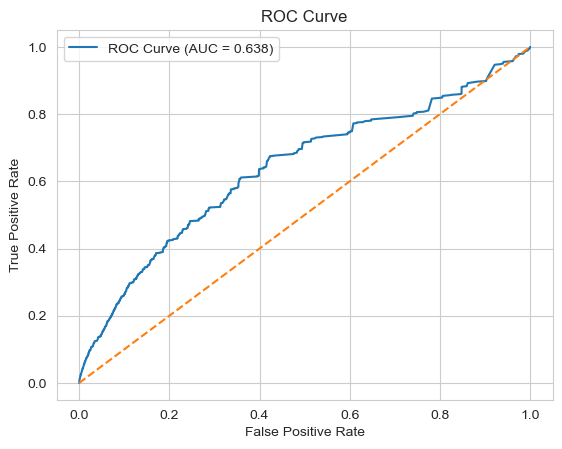

In [65]:
#plot ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### Interpretation
- Placement Instability (OR ≈ 2.1): Children flagged for instability have: ~2.1 times higher odds of negative exit compared to children without instability, holding other domains constant.
- Extended Care (OR ~4.2): Children flagged for extended care have: ~4.2 times higher odds of negative exit. This is the strongest predictor in your model. Chronic system involvement strongly correlates with system failure.
- Legal Permanancy: Children flagged for legal/permanency have: 75% lower odds of negative exit. This variable represents structured case progression, not instability.


Support: Class imbalance

Class 0 (non-negative exit): 175,940

Class 1 (negative exit): 21,019

Negative exits ≈ 10.7% of dataset

## Visualization: Key Findings

In [ ]:
thresholds_0_2 = thresholds_by_age['0-2']
age_0_2_labeled = create_outcome_labels(age_0_2, thresholds_0_2)

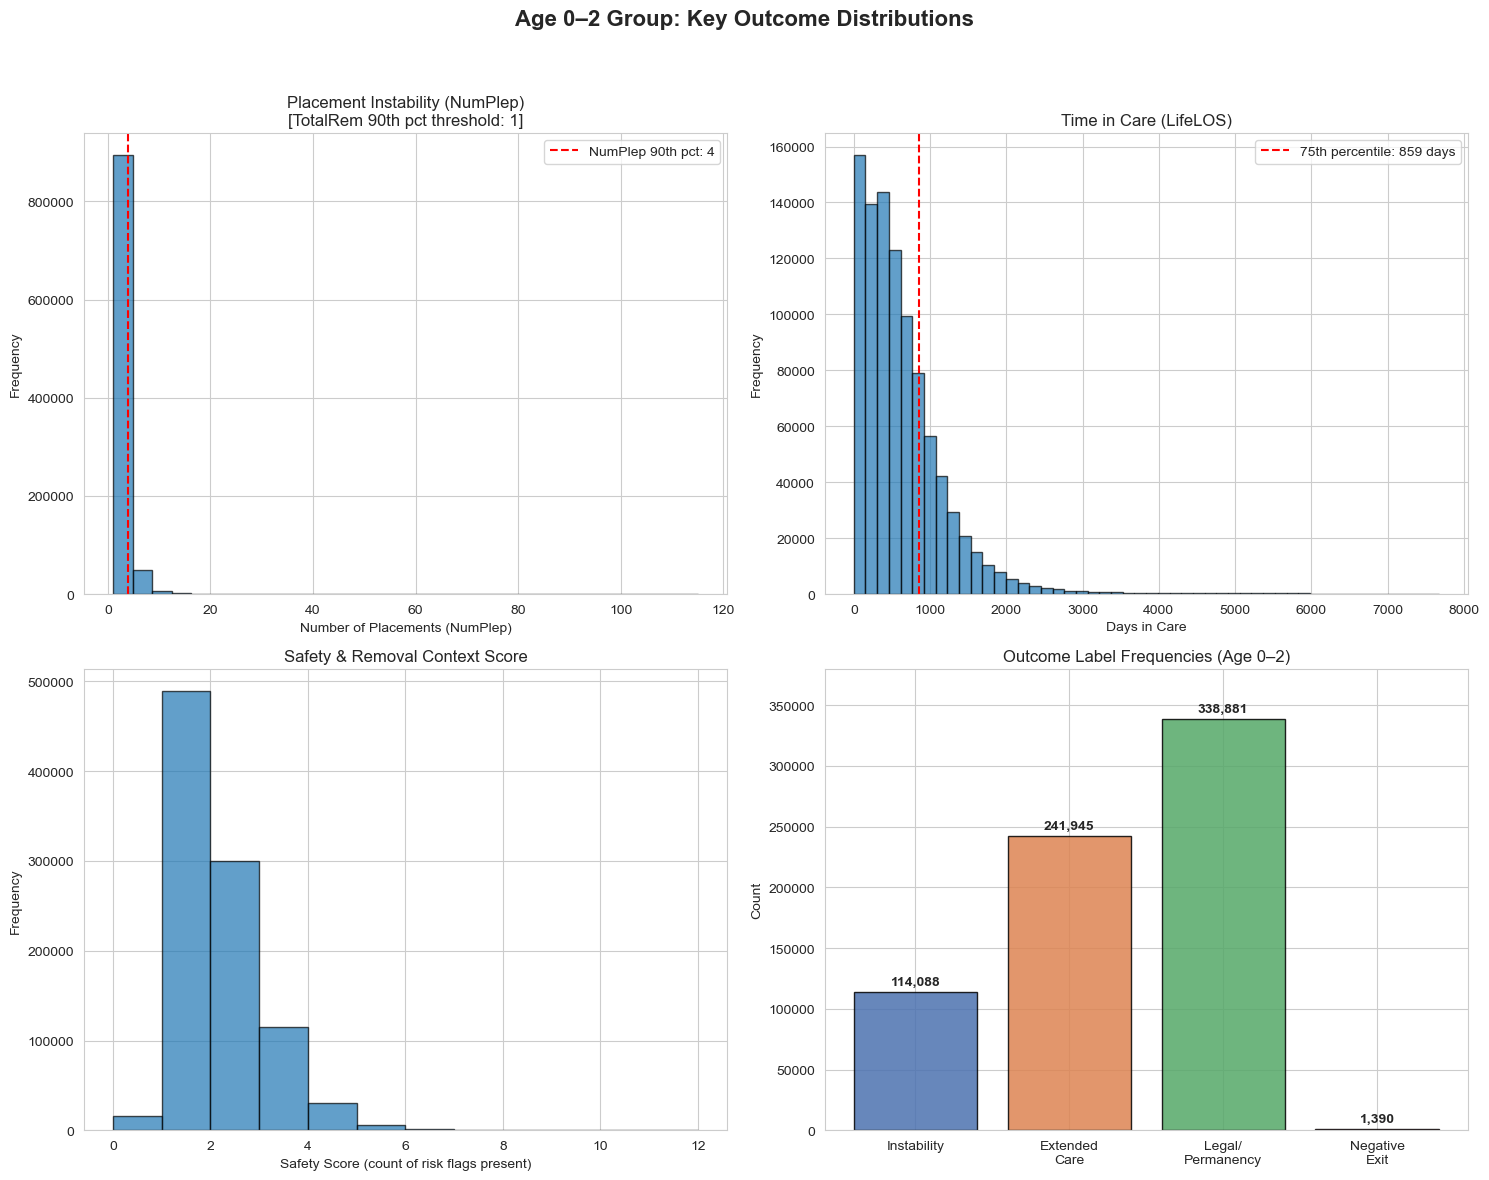


Visualization saved as 'age_0_2_outcomes.png'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Age 0–2 Group: Key Outcome Distributions', fontsize=16, fontweight='bold')

outcome_cols_local = [
    'outcome_instability',
    'outcome_extended_care',
    'outcome_legal_permanency',
    'outcome_negative_exit'
]

# ---------------- Plot 1: Placement Instability (NumPlep) ----------------
numplep_data = age_0_2['numplep'].dropna()
axes[0, 0].hist(numplep_data, bins=30, edgecolor='black', alpha=0.7)

numplep_thresh = thresholds_0_2['High Placement Instability']['numplep']
totalrem_thresh = thresholds_0_2['High Placement Instability']['totalrem']

axes[0, 0].axvline(numplep_thresh, color='red', linestyle='--',
                   label=f"NumPlep 90th pct: {numplep_thresh:.0f}")

axes[0, 0].set_xlabel('Number of Placements (NumPlep)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Placement Instability (NumPlep)\n[TotalRem 90th pct threshold: {totalrem_thresh:.0f}]')
axes[0, 0].legend()


# ---------------- Plot 2: Time in Care (LifeLOS) ----------------
lifelos_data = age_0_2['lifelos'].dropna()
axes[0, 1].hist(lifelos_data, bins=50, edgecolor='black', alpha=0.7)

los_thresh = thresholds_0_2['Extended Time in Care']['lifelos']
axes[0, 1].axvline(los_thresh, color='red', linestyle='--',
                   label=f"75th percentile: {los_thresh:.0f} days")

axes[0, 1].set_xlabel('Days in Care')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Time in Care (LifeLOS)')
axes[0, 1].legend()


# ---------------- Plot 3: Safety Score Distribution ----------------
safety_data = age_0_2['safety_score'].dropna()
axes[1, 0].hist(safety_data, bins=np.arange(0, safety_data.max() + 2),
                edgecolor='black', alpha=0.7)

axes[1, 0].set_xlabel('Safety Score (count of risk flags present)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Safety & Removal Context Score')


# ---------------- Plot 4: Outcome Labels ----------------
outcome_counts = age_0_2_labeled[outcome_cols_local].sum()

labels = ['Instability', 'Extended\nCare', 'Legal/\nPermanency', 'Negative\nExit']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = axes[1, 1].bar(labels, outcome_counts.values, color=colors, edgecolor='black', alpha=0.85)


for bar, count in zip(bars, outcome_counts.values):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (outcome_counts.max() * 0.01),
        f'{int(count):,}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Outcome Label Frequencies (Age 0–2)')
axes[1, 1].set_ylim(0, outcome_counts.max() * 1.12)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('age_0_2_outcomes.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'age_0_2_outcomes.png'")

In [ ]:
print("TotalRem distribution for age 0-2:")
print(age_0_2['totalrem'].value_counts().sort_index())
print()
print("LifeLOS null rate by TotalRem value:")
for val in [1, 2]:
    subset = age_0_2[age_0_2['totalrem'] == val]
    null_count = subset['lifelos'].isna().sum()
    print(f"  TotalRem={val}: {null_count:,} null LifeLOS ({null_count/len(subset)*100:.1f}%)")

subset_gt2 = age_0_2[age_0_2['totalrem'] > 2]
null_gt2 = subset_gt2['lifelos'].isna().sum()
print(f"  TotalRem>2:  {null_gt2:,} null LifeLOS ({null_gt2/len(subset_gt2)*100:.1f}% of {len(subset_gt2):,} cases)")

subset_null = age_0_2[age_0_2['totalrem'].isna()]
print(f"  TotalRem null: {len(subset_null):,} cases")

TotalRem distribution for age 0-2:
totalrem
1.0     902224
2.0      51315
3.0       3473
4.0        288
5.0         37
6.0          4
7.0          2
9.0          1
12.0         1
Name: count, dtype: int64

LifeLOS null rate by TotalRem value:
  TotalRem=1: 42 null LifeLOS (0.0%)
  TotalRem=2: 2,243 null LifeLOS (4.4%)
  TotalRem>2:  3,806 null LifeLOS (100.0% of 3,806 cases)
  TotalRem null: 952 cases


## Export Processed Data for Age 0-2 Group

In [ ]:
# # Save the labeled dataset for the 0-2 age group
# age_0_2_labeled.to_csv('/content/age_0_2_labeled_data.csv', index=False)
# print(f"Saved labeled data for age 0-2 group: {len(age_0_2_labeled):,} records")
# print(f"Columns: {list(age_0_2_labeled.columns)}")

## Modeling

#### Base Model: **Logistic Regression**

In [56]:
#train test split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

predictor_cols = [
    'outcome_instability',
    'outcome_extended_care',
    'outcome_legal_permanency'
]

X = model_data_clean[predictor_cols]
y = model_data_clean['outcome_negative_exit']

# Split data (stratify preserves class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

KeyError: "None of [Index(['outcome_instability', 'outcome_extended_care',\n       'outcome_legal_permanency'],\n      dtype='object')] are in the [columns]"